In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Create a highly imbalanced binary dataset (simulating Credit Card Fraud)
# weights=[0.97, 0.03] means only 3% are fraud — realistic imbalance
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    weights=[0.97, 0.03],   # 97% legitimate, 3% fraud
    flip_y=0,
    random_state=42
)

print("Dataset Shape      :", X.shape)
print("Legitimate (0)     :", np.sum(y == 0))
print("Fraud      (1)     :", np.sum(y == 1))
print(f"Imbalance Ratio    : {np.sum(y==0)/np.sum(y==1):.1f}:1")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTraining samples   :", X_train.shape[0])
print("Test samples       :", X_test.shape[0])
print("Fraud in test set  :", np.sum(y_test == 1))

Dataset Shape      : (10000, 20)
Legitimate (0)     : 9700
Fraud      (1)     : 300
Imbalance Ratio    : 32.3:1

Training samples   : 8000
Test samples       : 2000
Fraud in test set  : 60


In [3]:
# class_weight='balanced' adjusts for imbalance automatically
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Get predicted probabilities (needed for ROC, PR curves, threshold tuning)
y_proba = model.predict_proba(X_test)[:, 1]   # probability of being fraud (class 1)
y_pred  = model.predict(X_test)               # default threshold = 0.5

print("Model trained successfully.")
print(f"Training Accuracy  : {model.score(X_train, y_train)*100:.2f}%")
print(f"Test     Accuracy  : {model.score(X_test,  y_test )*100:.2f}%")

Model trained successfully.
Training Accuracy  : 85.84%
Test     Accuracy  : 85.95%


In [4]:
# ─────────────────────────────────────────────
# Build confusion matrix manually using NumPy
# ─────────────────────────────────────────────

def manual_confusion_matrix(y_true, y_pred):
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    return TP, TN, FP, FN

TP, TN, FP, FN = manual_confusion_matrix(y_test, y_pred)

print("Raw Confusion Matrix values (NumPy):")
print(f"  True  Positives (TP) = {TP}   <- Correctly identified fraud")
print(f"  True  Negatives (TN) = {TN}  <- Correctly identified legitimate")
print(f"  False Positives (FP) = {FP}   <- Legitimate flagged as fraud")
print(f"  False Negatives (FN) = {FN}   <- Fraud missed by model")

# ─────────────────────────────────────────────
# Manual metric formulas
# ─────────────────────────────────────────────

manual_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
manual_recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
manual_f1        = (2 * manual_precision * manual_recall / (manual_precision + manual_recall)
                   if (manual_precision + manual_recall) > 0 else 0.0)
manual_accuracy  = (TP + TN) / (TP + TN + FP + FN)

print("\n" + "="*55)
print("   MANUALLY COMPUTED METRICS (NumPy)")
print("="*55)
print(f"  Precision = TP/(TP+FP) = {TP}/({TP}+{FP}) = {manual_precision:.4f}")
print(f"  Recall    = TP/(TP+FN) = {TP}/({TP}+{FN}) = {manual_recall:.4f}")
print(f"  F1 Score  = 2*P*R/(P+R)              = {manual_f1:.4f}")
print(f"  Accuracy  = (TP+TN)/N                = {manual_accuracy:.4f}")
print("="*55)

Raw Confusion Matrix values (NumPy):
  True  Positives (TP) = 44   <- Correctly identified fraud
  True  Negatives (TN) = 1675  <- Correctly identified legitimate
  False Positives (FP) = 265   <- Legitimate flagged as fraud
  False Negatives (FN) = 16   <- Fraud missed by model

   MANUALLY COMPUTED METRICS (NumPy)
  Precision = TP/(TP+FP) = 44/(44+265) = 0.1424
  Recall    = TP/(TP+FN) = 44/(44+16) = 0.7333
  F1 Score  = 2*P*R/(P+R)              = 0.2385
  Accuracy  = (TP+TN)/N                = 0.8595


In [5]:
# Verify with sklearn's classification_report()

print("sklearn classification_report() Verification:")
print("-" * 55)
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

# Cross-check individual values
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
sk_p = precision_score(y_test, y_pred)
sk_r = recall_score(y_test, y_pred)
sk_f = f1_score(y_test, y_pred)
sk_a = accuracy_score(y_test, y_pred)

print("Cross-check (manual vs sklearn):")
print(f"  Precision : Manual={manual_precision:.4f}  |  sklearn={sk_p:.4f}  |  Match={np.isclose(manual_precision,sk_p)}")
print(f"  Recall    : Manual={manual_recall:.4f}  |  sklearn={sk_r:.4f}  |  Match={np.isclose(manual_recall,sk_r)}")
print(f"  F1 Score  : Manual={manual_f1:.4f}  |  sklearn={sk_f:.4f}  |  Match={np.isclose(manual_f1,sk_f)}")
print(f"  Accuracy  : Manual={manual_accuracy:.4f}  |  sklearn={sk_a:.4f}  |  Match={np.isclose(manual_accuracy,sk_a)}")

sklearn classification_report() Verification:
-------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       0.99      0.86      0.92      1940
       Fraud       0.14      0.73      0.24        60

    accuracy                           0.86      2000
   macro avg       0.57      0.80      0.58      2000
weighted avg       0.97      0.86      0.90      2000

Cross-check (manual vs sklearn):
  Precision : Manual=0.1424  |  sklearn=0.1424  |  Match=True
  Recall    : Manual=0.7333  |  sklearn=0.7333  |  Match=True
  F1 Score  : Manual=0.2385  |  sklearn=0.2385  |  Match=True
  Accuracy  : Manual=0.8595  |  sklearn=0.8595  |  Match=True


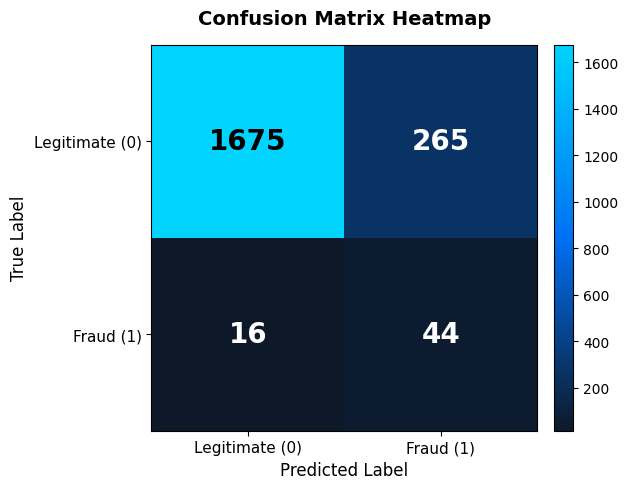

Confusion matrix saved.


In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

cmap = LinearSegmentedColormap.from_list('custom', ['#0d1929', '#0070f3', '#00d4ff'])
im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

labels = ['Legitimate (0)', 'Fraud (1)']
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        clr = 'white' if cm[i,j] < thresh else 'black'
        ax.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                fontsize=20, fontweight='bold', color=clr)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

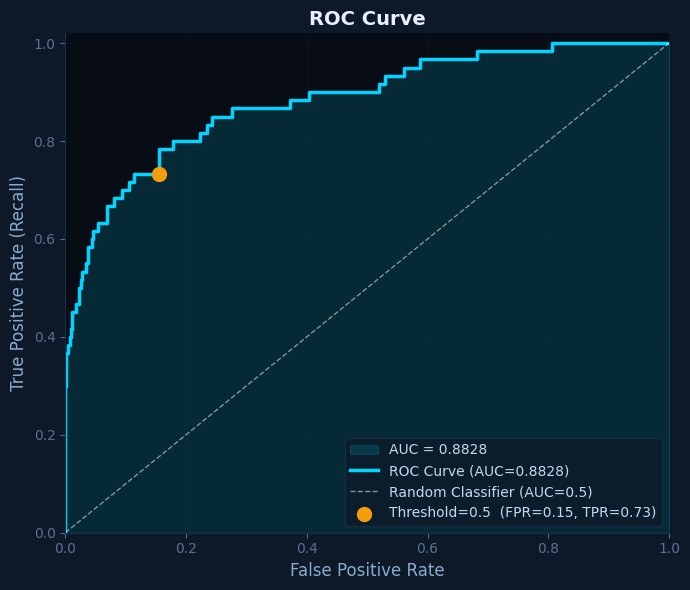

ROC AUC = 0.8828 | saved.


In [7]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))

# Shade AUC area
ax.fill_between(fpr, tpr, alpha=0.15, color='#00d4ff', label=f'AUC = {roc_auc:.4f}')
ax.plot(fpr, tpr, color='#00d4ff', linewidth=2.5, label=f'ROC Curve (AUC={roc_auc:.4f})')
ax.plot([0,1], [0,1], 'w--', linewidth=1, alpha=0.5, label='Random Classifier (AUC=0.5)')

# Mark default threshold point
idx_05 = np.argmin(np.abs(roc_thresholds - 0.5))
ax.scatter(fpr[idx_05], tpr[idx_05], s=100, color='#f59e0b',
           zorder=5, label=f'Threshold=0.5  (FPR={fpr[idx_05]:.2f}, TPR={tpr[idx_05]:.2f})')

ax.set_facecolor('#080c14')
fig.patch.set_facecolor('#0d1929')
ax.set_xlabel('False Positive Rate', fontsize=12, color='#8aaccc')
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12, color='#8aaccc')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold', color='#e8f0ff')
ax.tick_params(colors='#5a7090')
ax.spines['bottom'].set_color('#1a2e4a')
ax.spines['left'].set_color('#1a2e4a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.15, color='#1a2e4a')
ax.legend(fontsize=10, facecolor='#0d1929', labelcolor='#c8d6f0', edgecolor='#1a2e4a')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"ROC AUC = {roc_auc:.4f} | saved.")

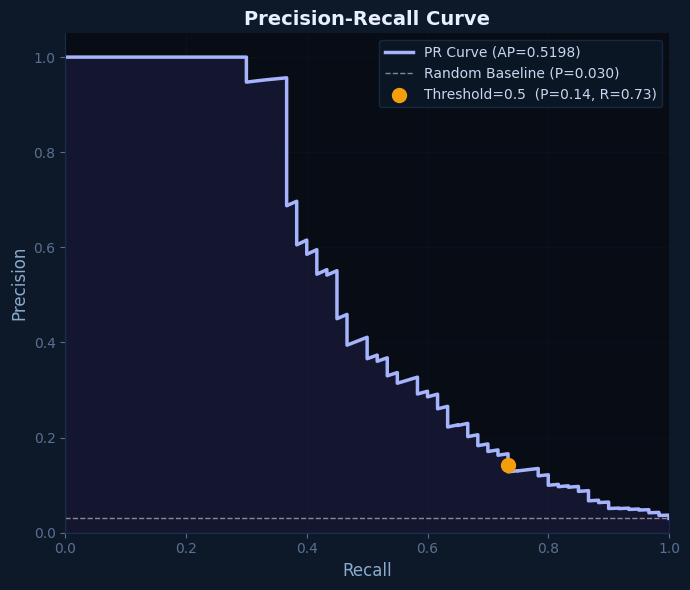

Average Precision = 0.5198 | saved.


In [8]:
precision_arr, recall_arr, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))

ax.fill_between(recall_arr, precision_arr, alpha=0.12, color='#6366f1')
ax.plot(recall_arr, precision_arr, color='#a5b4fc', linewidth=2.5,
        label=f'PR Curve (AP={avg_precision:.4f})')

# Baseline (random classifier for imbalanced data)
baseline = np.sum(y_test == 1) / len(y_test)
ax.axhline(baseline, color='white', linestyle='--', linewidth=1, alpha=0.5,
           label=f'Random Baseline (P={baseline:.3f})')

# Mark default threshold
idx_pr = np.argmin(np.abs(pr_thresholds - 0.5))
ax.scatter(recall_arr[idx_pr], precision_arr[idx_pr], s=100,
           color='#f59e0b', zorder=5,
           label=f'Threshold=0.5  (P={precision_arr[idx_pr]:.2f}, R={recall_arr[idx_pr]:.2f})')

ax.set_facecolor('#080c14')
fig.patch.set_facecolor('#0d1929')
ax.set_xlabel('Recall', fontsize=12, color='#8aaccc')
ax.set_ylabel('Precision', fontsize=12, color='#8aaccc')
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold', color='#e8f0ff')
ax.tick_params(colors='#5a7090')
for spine in ['bottom','left']:
    ax.spines[spine].set_color('#1a2e4a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.15, color='#1a2e4a')
ax.legend(fontsize=10, facecolor='#0d1929', labelcolor='#c8d6f0', edgecolor='#1a2e4a')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('pr_curve.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Average Precision = {avg_precision:.4f} | saved.")

## Step 7: Precision & Recall vs Classification Threshold (0.1 → 0.9)

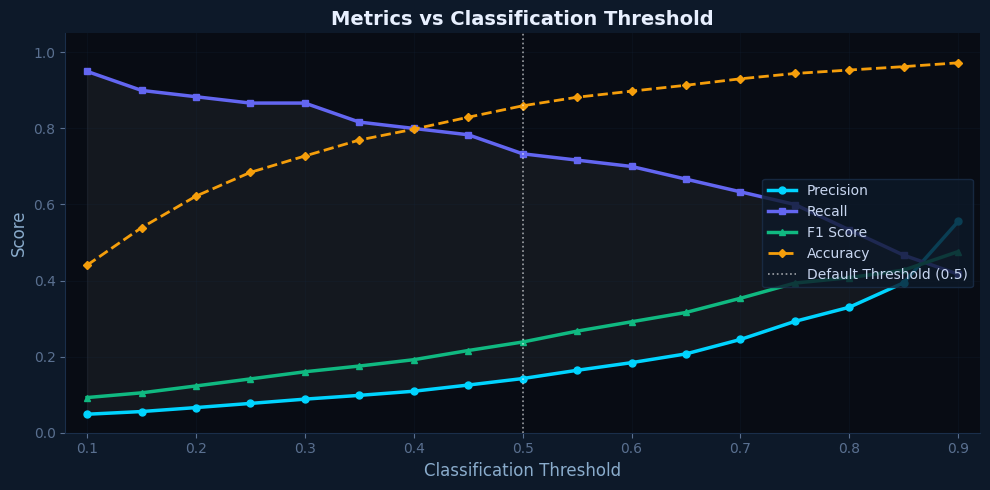

Threshold sweep plot saved.


In [9]:
thresholds = np.arange(0.1, 0.95, 0.05)
precisions = []
recalls    = []
f1_scores  = []
accuracies = []

for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    tp = np.sum((y_test==1)&(y_t==1))
    tn = np.sum((y_test==0)&(y_t==0))
    fp = np.sum((y_test==0)&(y_t==1))
    fn = np.sum((y_test==1)&(y_t==0))

    p  = tp/(tp+fp) if (tp+fp)>0 else 0.0
    r  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = 2*p*r/(p+r) if (p+r)>0 else 0.0
    ac = (tp+tn)/(tp+tn+fp+fn)

    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)
    accuracies.append(ac)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, precisions, color='#00d4ff', linewidth=2.5,
        marker='o', markersize=5, label='Precision')
ax.plot(thresholds, recalls,    color='#6366f1', linewidth=2.5,
        marker='s', markersize=5, label='Recall')
ax.plot(thresholds, f1_scores,  color='#10b981', linewidth=2.5,
        marker='^', markersize=5, label='F1 Score')
ax.plot(thresholds, accuracies, color='#f59e0b', linewidth=2.0,
        marker='D', markersize=4, linestyle='--', label='Accuracy')

ax.axvline(0.5, color='white', linestyle=':', linewidth=1.2, alpha=0.6, label='Default Threshold (0.5)')

# Fill between precision and recall to show tradeoff
ax.fill_between(thresholds, precisions, recalls, alpha=0.05, color='#ffffff')

ax.set_facecolor('#080c14')
fig.patch.set_facecolor('#0d1929')
ax.set_xlabel('Classification Threshold', fontsize=12, color='#8aaccc')
ax.set_ylabel('Score', fontsize=12, color='#8aaccc')
ax.set_title('Metrics vs Classification Threshold', fontsize=14, fontweight='bold', color='#e8f0ff')
ax.tick_params(colors='#5a7090')
for spine in ['bottom','left']:
    ax.spines[spine].set_color('#1a2e4a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.15, color='#1a2e4a')
ax.legend(fontsize=10, facecolor='#0d1929', labelcolor='#c8d6f0',
          edgecolor='#1a2e4a', loc='center right')
ax.set_xlim([0.08, 0.92]); ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('threshold_sweep.png', dpi=130, bbox_inches='tight')
plt.show()
print("Threshold sweep plot saved.")

In [10]:
# Full summary at default 0.5 threshold
print("=" * 60)
print("     FINAL METRICS SUMMARY  —  Threshold = 0.5")
print("=" * 60)
print(f"  {'Metric':<25} {'Manual (NumPy)':>15} {'sklearn':>10}")
print("-" * 60)
rows = [
    ("Precision",  manual_precision, sk_p),
    ("Recall",     manual_recall,    sk_r),
    ("F1 Score",   manual_f1,        sk_f),
    ("Accuracy",   manual_accuracy,  sk_a),
]
for name, m_val, s_val in rows:
    print(f"  {name:<25} {m_val:>15.4f} {s_val:>10.4f}")
print("-" * 60)
print(f"  {'ROC AUC':<25} {'':>15} {roc_auc:>10.4f}")
print(f"  {'Avg Precision (PR)':<25} {'':>15} {avg_precision:>10.4f}")
print("=" * 60)
print(f"  TP={TP}  TN={TN}  FP={FP}  FN={FN}")
print("=" * 60)

# DataFrame version
summary_df = pd.DataFrame({
    'Metric':         ['Precision','Recall','F1 Score','Accuracy','ROC AUC','Avg Precision'],
    'Manual (NumPy)': [manual_precision, manual_recall, manual_f1, manual_accuracy, '-', '-'],
    'sklearn':        [sk_p, sk_r, sk_f, sk_a, roc_auc, avg_precision]
})
print("\n")
print(summary_df.to_string(index=False))

     FINAL METRICS SUMMARY  —  Threshold = 0.5
  Metric                     Manual (NumPy)    sklearn
------------------------------------------------------------
  Precision                          0.1424     0.1424
  Recall                             0.7333     0.7333
  F1 Score                           0.2385     0.2385
  Accuracy                           0.8595     0.8595
------------------------------------------------------------
  ROC AUC                                       0.8828
  Avg Precision (PR)                            0.5198
  TP=44  TN=1675  FP=265  FN=16


       Metric Manual (NumPy)  sklearn
    Precision       0.142395 0.142395
       Recall       0.733333 0.733333
     F1 Score       0.238482 0.238482
     Accuracy         0.8595 0.859500
      ROC AUC              - 0.882826
Avg Precision              - 0.519800
